# Import libraries

In [1]:
import os
import pandas as pd
from pathlib import Path
import platform
import requests
import sys
from time import sleep
from tqdm.auto import tqdm
tqdm_bar_format = "{l_bar}{bar:10}| {n_fmt}/{total_fmt} [Elapsed:{elapsed}<Remaining:{remaining}{rate_fmt}{postfix}]"
import xmltodict


osName = platform.system()
if osName == 'Windows':
    dataverseFunctionsPath = os.path.join(
        'C:\\', 'Users', 'Owner', 'Documents', 'GitHub', 'dataverse-functions')
elif osName == 'Darwin':
    dataverseFunctionsPath = os.path.join(
        '/Users', 'juliangautier', 'dataverse-functions')
sys.path.append(dataverseFunctionsPath)  
from dataverse_functions import common_functions
from dataverse_functions import dataverse_functions

desktopPath = os.path.join(Path.home(), 'Desktop')

# Enter a user agent and your email address. Some Dataverse installations block requests from scripts.
# See https://www.whatismybrowser.com/detect/what-is-my-user-agent to get your user agent
userAgent = 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/81.0.4044.138 Safari/537.36'
emailAddress = 'juliangautier@g.harvard.edu'

headers = {
    'User-Agent': userAgent,
    'From': emailAddress}

filePath='/Users/juliangautier/Credentials/hdv_creds.yaml'
# filePath='/Users/juliangautier/Credentials/demo_creds.yaml'
credentials = common_functions.import_credentials(filePath=filePath)
installationUrl = credentials['installationURL']
apiKey = credentials['apiToken']

headers['X-Dataverse-key'] = apiKey

# Difference between dataset counts in GREI Metrics Dashboard and HDV monthly reports

As of September 21, 2026, [GREI Metrics Dashboard](https://commons.datacite.org/ror.org/01cwqze88?filterQuery=NOT+relatedIdentifiers.relationType=IsPartOf&organization-relation-type=fundedBy&client-id=gdcc.harvard-dv) tells users that there are 52 datasets in Harvard Dataverse from NIH funded research.

In our August 2026 monthly NIH funded datasets report, we wrote there are 431 datasets in Harvard Dataverse from NIH funded research.

Why are these two numbers so different?

The [GREI Metrics Dashboard](https://commons.datacite.org/ror.org/01cwqze88?filterQuery=NOT+relatedIdentifiers.relationType=IsPartOf&organization-relation-type=fundedBy&client-id=gdcc.harvard-dv) uses the DataCite API to find datasets where the funderIdentifier property is the ROR URL of the NIH or its centers and institutes. We've told Dataverse to send DataCite these ROR URLs in the funderIdentifier property when depositors use Dataverse's Funder Information Agency field and choose any of the NIH centers or institutes that the field suggests.

Our monthly report count also includes datasets where depositors have used Dataverse's Funder Information Agency field and chose any of the NIH centers or institutes that the field suggests, which makes Dataverse record the ROR URL of those NIH centers or institutes. Plus it includes datasets where depositors have entered any names and most acroynyms of the NIH centers and institutes into any of four fields of Dataverse's deposit form. The four fields, which we've found depositors commonly use to enter funder information, are the Description field, the Notes field, the Contributor field, and the Funder Information Agency field.

The August 2026 report's 431 datasets includes the 52 datasets we see in the GREI Metrics Dashboard, plus another 379 datasets.

Of those 379 datasets:
    - 5 datasets have ROR URLs in their Funder Information Agency fields, but a Dataverse bug has caused Dataverse to send this information to DataCite in the wrong way.
    - 374 datasets don't have ROR URLs in their Funder Information Agency fields, so the information that Dataverse sent to DataCite doesn't include funderIdentifier properties with the ROR URLs of NIH centers or institutes

## Create chart vizualizing difference between counts

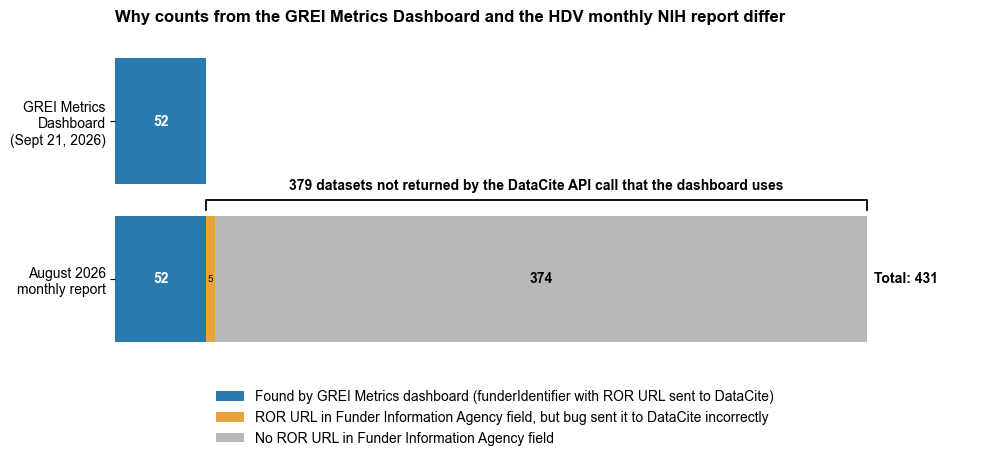

In [3]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

dashboard = 52
bug = 5
no_ror = 374
extra = bug + no_ror              # 379
report_total = dashboard + extra  # 431

fig, ax = plt.subplots(figsize=(10, 4.5))
# fig, ax = plt.subplots(figsize=(15, 4.5))

labels = ["August 2026\nmonthly report", "GREI Metrics\nDashboard\n(Sept 21, 2026)"]

c_dash = "#2a7ab0"
c_bug = "#e8a33d"
c_none = "#b8b8b8"

# Monthly report: three stacked segments (y = 0)
ax.barh(0, dashboard, color=c_dash,
        label="Found by GREI Metrics dashboard (funderIdentifier with ROR URL sent to DataCite)")
ax.barh(0, bug, left=dashboard, color=c_bug,
        label="ROR URL in Funder Information Agency field, but bug sent it to DataCite incorrectly")
ax.barh(0, no_ror, left=dashboard + bug, color=c_none,
        label="No ROR URL in Funder Information Agency field")

# Dashboard: one segment (y = 1)
ax.barh(1, dashboard, color=c_dash)

# Value labels
ax.text(dashboard / 2, 0, str(dashboard), ha="center", va="center",
        color="white", fontweight="bold")
ax.text(dashboard + bug + no_ror / 2, 0, str(no_ror), ha="center", va="center",
        fontweight="bold")

# ax.text(dashboard + bug / 2, -0.32, str(bug), ha="center", va="center", fontsize=9)
ax.text(dashboard + bug / 2, 0, str(bug), ha="center", va="center", fontsize=7)

ax.text(report_total + 4, 0, f"Total: {report_total}", va="center", fontweight="bold")
ax.text(dashboard / 2, 1, str(dashboard), ha="center", va="center",
        color="white", fontweight="bold")

# Bracket over the 279 "extra" datasets
bracket_y = 0.5        # just above the top edge of the bar (bar spans -0.4 to 0.4)
tick = 0.06            # height of the bracket's end ticks
x_start = dashboard
x_end = report_total
ax.plot([x_start, x_start, x_end, x_end],
        [bracket_y - tick, bracket_y, bracket_y, bracket_y - tick],
        color="black", linewidth=1.3, clip_on=False)
ax.text((x_start + x_end) / 2, bracket_y + 0.05,
        f"{extra} datasets not returned by the DataCite API call that the dashboard uses",
        ha="center", va="bottom", fontweight="bold")

ax.set_yticks([0, 1])
ax.set_yticklabels(labels)
ax.set_xlim(0, report_total * 1.15)

for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

ax.set_ylim(-0.6, 1.5)
ax.set_title("Why counts from the GREI Metrics Dashboard and the HDV monthly NIH report differ",
             loc="left", fontweight="bold", pad=15)

for side in ("top", "right"):
    ax.spines[side].set_visible(False)

ax.legend(loc="upper center",
          bbox_to_anchor=(0.5, 0.15),
          bbox_transform=fig.transFigure,   # anchor to the figure, not the axes
          frameon=False, ncol=1)

plt.tight_layout()
plt.savefig("nih_dataset_counts.png", dpi=200)
plt.show()

## Get lists of PIDs from the GREI Metrics Dashboard counts and from the HDV monthly report counts

The dataset PIDs from the HDV monthly report are in [a Google Sheet](https://docs.google.com/spreadsheets/d/1z5lz6QaETr8cI-7LhCBb44_-AZ-lA0UnThXqKkL0xxQ), which includes:
- a column to show if each dataset has an NIH ROR URL in its Funder Information Agency fields
- a column to show if each dataset is among the datasets we see on the GREI Metrics Dashboard, which are the datasets returned by [a DataCite API call](https://api.datacite.org/dois?funded-by=https://ror.org/01cwqze88&include-funder-child-organizations=true&client-id=gdcc.harvard-dv).

# Difference between dataset counts returned by DataCite API call for datasets with any funderIdentifiers and dataset counts returned by Harvard Dataverse with a ROR URL in their Funder Information Agency field

In [ ]:
# Get list of PIDs from DataCite
searchUrl = 'https://api.datacite.org/dois?client-id=gdcc.harvard-dv&query=fundingReferences.funderIdentifier%3A*&registered=&resource-type-id=&state=findable&affiliation=true&publisher=true'
datasetPidsFromDataCiteList = common_functions.get_dataset_pids_from_datacite_api(searchUrl)

print(len(datasetPidsFromDataCiteList))
print(datasetPidsFromDataCiteList[0])

In [ ]:
# Get list of PIDs from Harvard Dataverse

searchUrl = 'https://dataverse.harvard.edu/dataverse/harvard?q=grantNumberAgency:"https://ror.org/"&fq1=metadataSource:"Harvard+Dataverse"&types=datasets&fq2=publicationStatus:"Published"'
apiSearchUrl = dataverse_functions.get_search_api_url(searchUrl)

datasetInfoDf = dataverse_functions.get_datasets_from_collection_or_search_url(
    url=searchUrl, headers=headers, apiKey='', metadataFieldsParam=None,
    ignoreDeaccessionedDatasets=True,
    includeSubDataverses=False, includeLinkedDatasets=False, includeHarvestedDatasets=False,
    printProgress=True)
datasetPidsFromHDVList = datasetInfoDf['dataset_pid'].to_list()
print(len(datasetPidsFromHDVList))

common_functions.export_list_to_txt_file(datasetPidsFromHDVList)

In [ ]:
datasetInfoDf.to_csv(os.path.join(desktopPath, 'datasetInfoDf.csv'), index=False, encoding='utf-8-sig')

In [ ]:
# Compare the two lists of PIDs
pidsInDataCiteNotInHDVList = list(set(datasetPidsFromDataCiteList) - set(datasetPidsFromHDVList))
print(f'Datasets in DataCite but not in HDV: {len(pidsInDataCiteNotInHDVList)}')

pidsInHDVNotInDataCiteList = list(set(datasetPidsFromHDVList) - set(datasetPidsFromDataCiteList))
print(f'Datasets in HDV but not in DataCite: {len(pidsInHDVNotInDataCiteList)}')

In [ ]:
for i in pidsInDataCiteNotInHDVList:
    print(i)

In [ ]:
# Get dataframe with information about datasets with funderIdentifiers in DataCite that don't have funder agency RORs in HDV

pidsInDataCiteNotInHDVDf = dataverse_functions.get_dataset_info_from_dataset_pid_list(
    datasetPidList=pidsInDataCiteNotInHDVList,
    installationUrl=installationUrl,
    headers=headers,
    apiKey=apiKey,
    metadataFieldsParam=None)

pidsInDataCiteNotInHDVDf.head()

In [ ]:
headers.pop('X-Dataverse-key', None)
datasetPidsList = [
    'doi:10.7910/DVN/4MYRSF',
    'doi:10.7910/DVN/PR2C7H',
    'doi:10.7910/DVN/PYJSYC',
    'doi:10.7910/DVN/UOYNBB',
    'doi:10.7910/DVN/ZBYVFY'
]

# datasetPidsList = [
#     # 'doi:10.7910/DVN/JQVK0V',
#     'doi:10.7910/DVN/VMVCQN '
# ]

# Check if each dataset's Datacite export has any funderIdentifiers
with requests.Session() as session:

    loopObj = tqdm(bar_format=tqdm_bar_format, iterable=pidsInHDVNotInDataCiteList)
    for datasetPid in loopObj:
        loopObj.set_postfix_str(datasetPid)
    # for datasetPid in pidsInHDVNotInDataCiteList:
        dataCiteExportXml = dataverse_functions.get_dataset_metadata_export(
            installationUrl, datasetPid=datasetPid, exportFormat='Datacite',
            session=session, timeout=60, verify=False, excludeFiles=True,
            returnOwners=False, version=':latest',
            headers=headers,
            apiKey='')
        datasetPidUrl = common_functions.get_url_form_of_pid(datasetPid)
        # print(dataCiteExportXml)
        if dataCiteExportXml.startswith('ERROR'):
            print(f'{datasetPidUrl} Datacite export error!')
        else:
            dataCiteExportDict = xmltodict.parse(dataCiteExportXml)
            fundingReferences = common_functions.improved_get(dataCiteExportDict, 'resource.fundingReferences.fundingReference')
            funderIdentifiersList = []
            if fundingReferences is not None:
                if isinstance(fundingReferences, dict):
                    funderIdentifier = common_functions.improved_get(fundingReferences, 'funderIdentifier')
                    if funderIdentifier is not None:
                        funderIdentifiersList.append(funderIdentifier)
                if isinstance(fundingReferences, list):
                    for fundingReference in fundingReferences:
                        funderIdentifier = common_functions.improved_get(fundingReference, 'funderIdentifier')
                        if funderIdentifier is not None:
                            funderIdentifiersList.append(funderIdentifier)
            if funderIdentifiersList == []:
                hasFunderIdentifiers = False
            elif len(funderIdentifiersList) > 0:
                hasFunderIdentifiers = True

            # Save print to text file on Desktop
            outputFilePath = os.path.join(desktopPath, 'datacite_funder_identifiers_check.txt')
            with open(outputFilePath, 'a') as f:
                f.write(f'{datasetPidUrl} Datacite export has funderIdentifier(s): {hasFunderIdentifiers}\n')

            sleep(1)

Datasets with NIH RORs in funder metadata but not included in DataCite API:
- doi:10.7910/DVN/4MYRSF
- doi:10.7910/DVN/PR2C7H
- doi:10.7910/DVN/PYJSYC
- doi:10.7910/DVN/UOYNBB
- doi:10.7910/DVN/ZBYVFY

In the DataCite export of doi:10.7910/DVN/PR2C7H, the ROR is in the funderName property, e.g. <funderName>https://ror.org/013kjyp64</funderName>.

The ROR ID should be in the funderIdentifier property, e.g. <funderIdentifier funderIdentifierType="ROR" schemeURI="https://ror.org">https://ror.org/04byxyr05</funderIdentifier>
DataCite export of the dataset at doi:10.7910/DVN/JQVK0V.

I thnk this was reported by someone else in the Dataverse community and might have been fixed in either the Dataverse software or the controlled vocab functionality code or both, but isn't fixed for this and possibly other datasets in Harvard Dataverse.

### Next steps
- Review the DataCite exports of the other 4 datasets
- Get the diff between datasets returned by:
    - Search of HDV datasets with RORs in the funder information field, which returned 226 on 2026-09-01: https://dataverse.harvard.edu/dataverse/harvard?q=grantNumberAgency%3A%22https%3A%2F%2Fror.org%2F%22&fq1=metadataSource%3A%22Harvard+Dataverse%22&fq0=dvObjectType%3A%28datasets%29&types=datasets&sort=score&order=
    - Search of HDV datsaets from DataCite API with funderIdentifier, which returned 200 on 2026-09-01: https://dataverse.harvard.edu/dataverse/harvard?q=grantNumberAgency%3A%22https%3A%2F%2Fror.org%2F%22&fq1=metadataSource%3A%22Harvard+Dataverse%22&fq0=dvObjectType%3A%28datasets%29&types=datasets&sort=score&order=
- Review the DataCite exports of the datasets that are not in both lists

## Evaluating effectiveness of Funding Information field redesign

- How many published datasets in HDV have anything in the Funding Information Agency fields of their latest published versions?
- Of those, how many have ROR URLs in the Funding Information Agency fields of their latest published versions?
    - How many of those were first published before the Funding Information field redesign?
    - How many of those were first published after the Funding Information field redesign?
- Of those, how many don't have ROR URLs in the Funding Information Agency fields of their latest published versions?
    - How many of those were first published before the Funding Information field redesign?
    - How many of those were first published after the Funding Information field redesign?